In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt




In [3]:
df = pd.read_csv("Q33_hotel_booking.csv")
print(df.head())
print(df.info())

  booking_id booking_date room_type    season booking_channel  \
0    HT00001   2026-03-22     Suite       Low             OTA   
1    HT00002   2026-01-24  Standard       Low          Direct   
2    HT00003   2026-06-01  Standard  Shoulder       Corporate   
3    HT00004   2026-02-10    Deluxe      Peak          Direct   
4    HT00005   2026-04-26  Standard  Shoulder       Corporate   

  cancellation_status  occupancy  
0                  No        0.0  
1                  No        1.0  
2                  No        1.0  
3                  No        0.0  
4                  No        1.0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   booking_id           123 non-null    object 
 1   booking_date         123 non-null    object 
 2   room_type            123 non-null    object 
 3   season               121 non-null    obj

In [4]:
print(df.isnull().sum())

booking_id             0
booking_date           0
room_type              0
season                 2
booking_channel        0
cancellation_status    0
occupancy              1
dtype: int64


In [ ]:
print("Duplicate records:", df.duplicated().sum())
df = df.drop_duplicates()
print("Records after removing duplicates:", len(df))

In [5]:
df['booking_date'] = pd.to_datetime(df['booking_date'])

In [6]:
def get_season(month):
    if month in [1, 2]:
        return "Low"
    elif month in [3, 4, 5]:
        return "Shoulder"
    else:
        return "Peak"
df['season'] = df['booking_date'].dt.month.apply(get_season)
print(df[['booking_date', 'season']].head())

  booking_date    season
0   2026-03-22  Shoulder
1   2026-01-24       Low
2   2026-06-01      Peak
3   2026-02-10       Low
4   2026-04-26  Shoulder


In [8]:
df['room_type'] = df['room_type'].str.strip().str.title()

In [9]:
df['booking_channel'] = df['booking_channel'].str.strip().str.title()
df['cancellation_status'] = df['cancellation_status'].str.strip().str.title()

In [10]:
group_mean = df.groupby(
    ['room_type', 'season', 'booking_channel']
)['occupancy'].transform('mean')
df['occupancy'] = df['occupancy'].fillna(group_mean)
print(df.isnull().sum())

booking_id             0
booking_date           0
room_type              0
season                 0
booking_channel        0
cancellation_status    0
occupancy              0
dtype: int64


In [11]:
overall_occupancy = df['occupancy'].mean() * 100

print("Overall Occupancy Rate:",
      round(overall_occupancy, 2), "%")

Overall Occupancy Rate: 55.28 %


In [12]:
season_occupancy = df.groupby('season')['occupancy'].mean() * 100
print(season_occupancy)

season
Low         59.259259
Peak        57.575758
Shoulder    52.380952
Name: occupancy, dtype: float64


In [13]:
room_occupancy = df.groupby('room_type')['occupancy'].mean() * 100
print(room_occupancy)

room_type
Deluxe      63.829787
Standard    45.238095
Suite       55.882353
Name: occupancy, dtype: float64


In [15]:
channel_occupancy = df.groupby(
    'booking_channel'
)['occupancy'].mean() * 100

print(channel_occupancy)

booking_channel
Corporate    51.063830
Direct       60.526316
Ota          55.263158
Name: occupancy, dtype: float64


In [16]:
channel_occupancy = df.groupby(
    'booking_channel'
)['occupancy'].mean() * 100

print(channel_occupancy)

booking_channel
Corporate    51.063830
Direct       60.526316
Ota          55.263158
Name: occupancy, dtype: float64


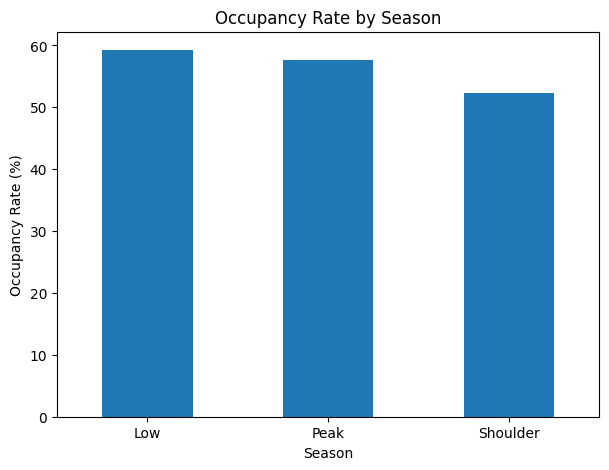

In [18]:
season_occupancy.plot(
    kind='bar',
    figsize=(7,5),
    title='Occupancy Rate by Season'
)
plt.xlabel('Season')
plt.ylabel('Occupancy Rate (%)')
plt.xticks(rotation=0)
plt.show()

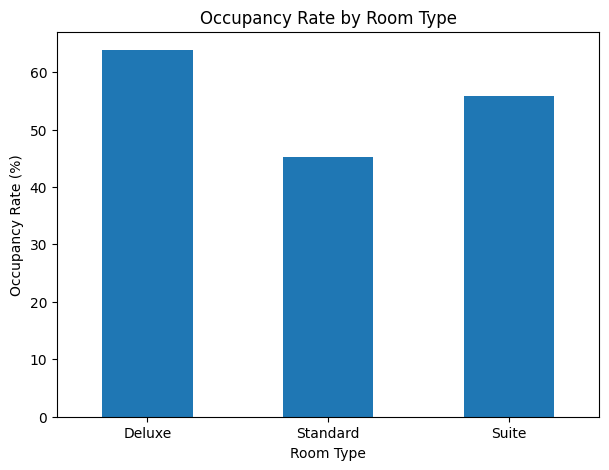

In [19]:
room_occupancy.plot(
    kind='bar',
    figsize=(7,5),
    title='Occupancy Rate by Room Type'
)

plt.xlabel('Room Type')
plt.ylabel('Occupancy Rate (%)')
plt.xticks(rotation=0)
plt.show()

In [20]:
monthly_occupancy = df.groupby(
    df['booking_date'].dt.to_period('M')
)['occupancy'].mean() * 100

print(monthly_occupancy)

booking_date
2026-01    64.285714
2026-02    53.846154
2026-03    55.000000
2026-04    60.869565
2026-05    40.000000
2026-06    58.333333
2026-07    55.555556
Freq: M, Name: occupancy, dtype: float64


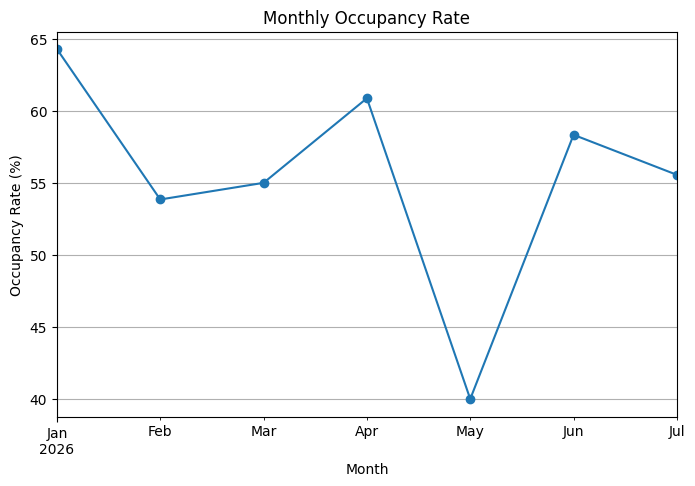

In [21]:
monthly_occupancy.plot(
    kind='line',
    marker='o',
    figsize=(8,5),
    title='Monthly Occupancy Rate'
)

plt.xlabel('Month')
plt.ylabel('Occupancy Rate (%)')
plt.grid(True)
plt.show()

In [22]:
low_months = monthly_occupancy[
    monthly_occupancy < 50
]

print("Low Occupancy Months:")
print(low_months)

Low Occupancy Months:
booking_date
2026-05    40.0
Freq: M, Name: occupancy, dtype: float64


In [23]:
low_rooms = room_occupancy[
    room_occupancy < 50
]

print("Low Occupancy Room Types:")
print(low_rooms)

Low Occupancy Room Types:
room_type
Standard    45.238095
Name: occupancy, dtype: float64
